In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Load x_data and y_data
x_data = pd.read_csv('../data/x_data.csv')
raw_y_data = pd.read_csv('../data/y_data.csv')
raw_y_data['gameId'] = raw_y_data["game_id"]
# Step 1: One-hot encode categorical features
categorical_features = ['possessionTeam', 'defensiveTeam', 'offenseFormation', 'receiverAlignment']
one_hot_encoder = OneHotEncoder(sparse=False, drop='first')
encoded_features = one_hot_encoder.fit_transform(x_data[categorical_features])
encoded_feature_names = one_hot_encoder.get_feature_names_out(categorical_features)
x_encoded = pd.DataFrame(encoded_features, columns=encoded_feature_names)

# Drop original categorical columns and concatenate one-hot encoded features
x_data = pd.concat([x_data.drop(columns=categorical_features), x_encoded], axis=1)

# Step 2: Normalize numerical features
numerical_features = [col for col in x_data.columns if col not in ['gameId', 'playId'] + list(encoded_feature_names)]
scaler = MinMaxScaler()
x_data[numerical_features] = scaler.fit_transform(x_data[numerical_features])




c:\Users\jesse\anaconda3\envs\hawks\lib\site-packages\sklearn\preprocessing\_encoders.py:972: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Text(0, 0.5, 'Downfield Displayment (Feet)')

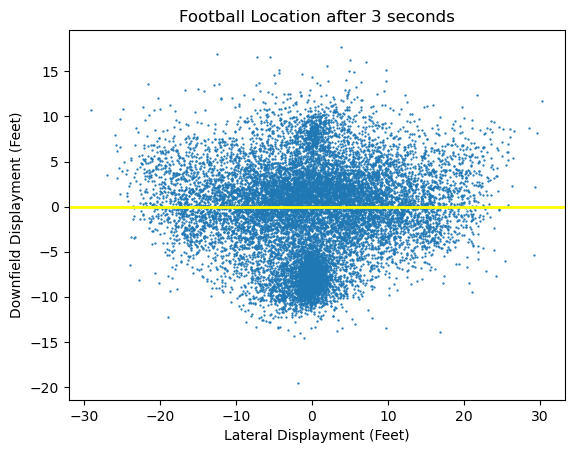

In [2]:
import matplotlib.pyplot as plt
plt.scatter( raw_y_data["dy"], raw_y_data["dx"], s= .4)
plt.axhline(y=0, color='yellow', linewidth=2, label="Zero Line")
plt.title("Football Location after 3 seconds")
plt.xlabel("Lateral Displayment (Feet)")
plt.ylabel("Downfield Displayment (Feet)")


In [3]:

# Step 3: Align x_data and y_data by gameId and playId
merged_data = x_data.merge(raw_y_data[['gameId', 'playId', 'dx', 'dy']], on=['gameId', 'playId'], how='inner')
x_data = merged_data.drop(columns=['dx', 'dy'])
y_data = merged_data[['dx', 'dy']]

In [4]:
y_data["dy"].min()

-29.01999950408937

In [5]:
# Step 4: Prepare y_data as n x m probability matrices
n_bins = 40  # Adjust as needed for resolution
m_bins = 60

dx_bins = np.linspace(-20, 20, n_bins + 1)
dy_bins = np.linspace(-30, 30, m_bins + 1)



def create_probability_matrix(dx, dy):
    dx_idx = min(max(np.digitize(dx, dx_bins) - 1, 0), n_bins - 1)  # Clamp to [0, n_bins - 1]
    dy_idx = min(max(np.digitize(dy, dy_bins) - 1, 0), m_bins - 1)  # Clamp to [0, m_bins - 1]
    matrix = np.zeros((n_bins, m_bins))
    matrix[dx_idx, dy_idx] = 1
    return matrix


y_data_probabilities = np.array([create_probability_matrix(row['dx'], row['dy']) for _, row in y_data.iterrows()])



In [6]:

# Step 5: Train-test split
x_train, x_test, y_train, y_test = train_test_split(x_data.drop(columns=['gameId', 'playId']), y_data_probabilities, test_size=0.2, random_state=42)


y_train_flat = y_train.reshape(-1, 2400)
y_test_flat = y_test.reshape(-1, 2400)
# Step 6: Define and train a neural network model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(x_train.shape[1],)),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3), 
    tf.keras.layers.Dense(n_bins * m_bins, activation='softmax')  # Output probabilities
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Reshape y_train and y_test to match model output
y_train_reshaped = y_train_flat.reshape(y_train.shape[0], -1)
y_test_reshaped = y_test_flat.reshape(y_test.shape[0], -1)

model.fit(x_train, y_train_reshaped, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
evaluation = model.evaluate(x_test, y_test_reshaped)
print(f"Test loss: {evaluation[0]}, Test accuracy: {evaluation[1]}")

c:\Users\jesse\anaconda3\envs\hawks\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.0165 - loss: 7.0670 - val_accuracy: 0.0151 - val_loss: 6.5025
Epoch 2/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0194 - loss: 6.2976 - val_accuracy: 0.0143 - val_loss: 6.4772
Epoch 3/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0199 - loss: 6.2636 - val_accuracy: 0.0151 - val_loss: 6.4626
Epoch 4/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0215 - loss: 6.1831 - val_accuracy: 0.0095 - val_loss: 6.4587
Epoch 5/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0242 - loss: 6.1525 - val_accuracy: 0.0135 - val_loss: 6.4668
Epoch 6/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0207 - loss: 6.0941 - val_accuracy: 0.0103 - val_loss: 6.5097
Epoch 7/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0228 - loss: 6.0631 - val_accuracy: 0.0111 - val_loss: 6.5102
Epoch 8/10
354/354 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0185 - loss: 6.0164 - val_accuracy: 0.

In [7]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

# Compile the model
model.compile(
    optimizer='adam',  # Choose your optimizer
    loss='categorical_crossentropy',  # Use the appropriate loss function
    metrics=['accuracy']  # Monitor accuracy
)

# Define callbacks
callbacks = [
    ModelCheckpoint(
        filepath='best_model.keras',  # File to save the best model
        monitor='val_accuracy',  # Metric to monitor
        save_best_only=True,  # Save only when val_accuracy improves
        mode='max',  # Maximize the monitored metric
        verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy',  # Metric to monitor
        patience=10,  # Stop training after 10 epochs with no improvement
        mode='max',
        verbose=1
    )
]

# Train the model
history = model.fit(
    x_train, y_train_flat,  # Training data
    validation_data=(x_test, y_test_flat),  # Validation data
    epochs=100,  # Maximum number of epochs
    batch_size=32,  # Adjust batch size as needed
    callbacks=callbacks  # Add the callbacks
)


Epoch 1/100
387/394 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0230 - loss: 6.0225
Epoch 1: val_accuracy improved from -inf to 0.01940, saving model to best_model.keras
394/394 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.0230 - loss: 6.0232 - val_accuracy: 0.0194 - val_loss: 6.4294
Epoch 2/100
394/394 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0252 - loss: 5.9665
Epoch 2: val_accuracy improved from 0.01940 to 0.02130, saving model to best_model.keras
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0252 - loss: 5.9666 - val_accuracy: 0.0213 - val_loss: 6.4590
Epoch 3/100
391/394 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0254 - loss: 5.9294
Epoch 3: val_accuracy improved from 0.02130 to 0.02162, saving model to best_model.keras
394/394 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.0254 - loss: 5.9295 - val_accuracy: 0.0216 - val_loss: 6.5037
Epoch 4/100
393/394 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0291 - loss: 5.8863
Epoch 4: val_accuracy did not improve

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_play_prediction(game_id, play_id, x_data, y_data, model, dx_bins, dy_bins):
    """
    Generate predictions for a specific play and visualize the results with a heatmap.
    
    Parameters:
    - game_id: The game ID for the play.
    - play_id: The play ID for the play.
    - x_data: The processed feature dataset.
    - y_data: The processed target probability matrices.
    - model: The trained model.
    - dx_bins: Bins for the dx feature.
    - dy_bins: Bins for the dy feature.
    """
    # Step 1: Extract the play's processed data
    play_data = x_data[(x_data['gameId'] == game_id) & (x_data['playId'] == play_id)]
    
    if play_data.empty:
        print("Play not found!")
        return
    
    # Drop 'gameId' and 'playId' columns to match model input
    play_input = play_data.drop(columns=['gameId', 'playId']).values

    # Step 2: Get model predictions
    print(play_input.shape)

    predictions = model.predict(play_input.reshape(1,-1))
    predicted_probs = predictions.reshape(len(dx_bins) - 1, len(dy_bins) - 1)
    
    # # Step 3: Get truth data
    # truth_matrix = y_data[(y_data['gameId'] == game_id) & (y_data['playId'] == play_id)].values
    # truth_matrix = truth_matrix.reshape(len(dx_bins) - 1, len(dy_bins) - 1)
    
    # Step 4: Create a heatmap for predictions
    plt.figure(figsize=(12, 8))
    sns.heatmap(predicted_probs, cmap="coolwarm", xticklabels=np.round(dy_bins, 1), yticklabels=np.round(dx_bins, 1))
    plt.title(f"Predicted Heatmap for Game {game_id}, Play {play_id}")
    plt.xlabel("dy (yards)")
    plt.ylabel("dx (yards)")
    
    # # Step 5: Overlay truth data
    # truth_indices = np.argwhere(truth_matrix == 1)
    # for (dx_idx, dy_idx) in truth_indices:
    #     plt.scatter(dy_idx + 0.5, dx_idx + 0.5, color='green', s=100, label='Truth', edgecolor='black', zorder=5)
    
    plt.legend(['Truth'])
    plt.show()


(1, 88)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


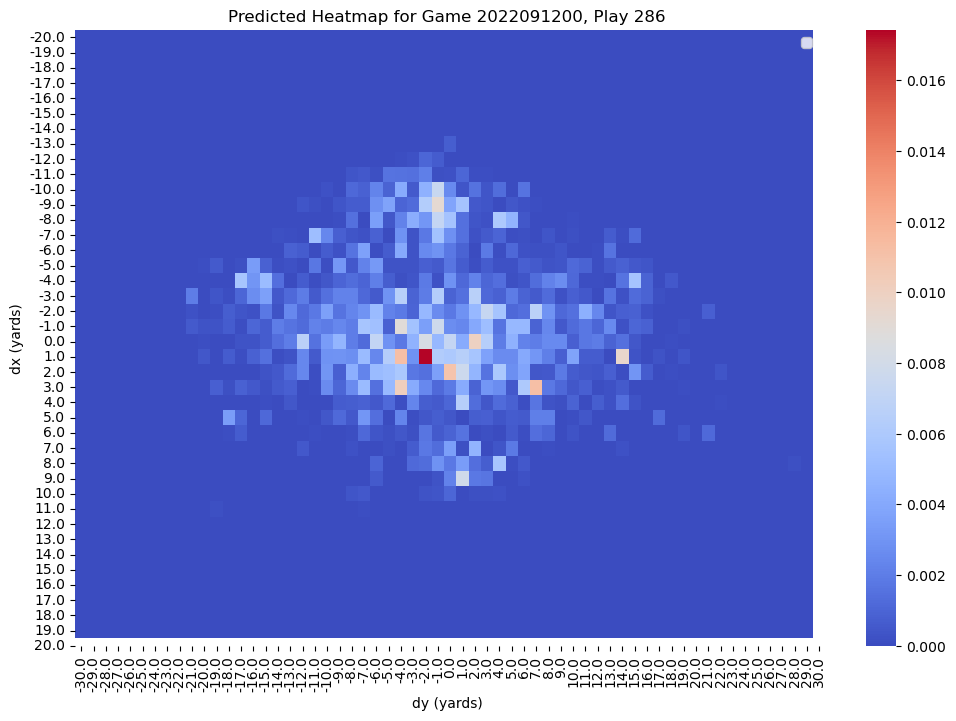

In [9]:
plot_play_prediction(
    game_id=2022091200,
    play_id=286,
    x_data=x_data,
    y_data=y_data_probabilities,
    model=model,
    dx_bins=dx_bins,
    dy_bins=dy_bins
)


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_play_prediction(game_id, play_id, x_data, y_data, model, dx_bins, dy_bins):
    """
    Generate predictions for a specific play and visualize the results with a heatmap.

    Parameters:
    - game_id: The game ID for the play.
    - play_id: The play ID for the play.
    - x_data: The processed feature dataset.
    - y_data: The DataFrame with true dx and dy values.
    - model: The trained model.
    - dx_bins: Bins for the dx feature.
    - dy_bins: Bins for the dy feature.
    """
    # Step 1: Extract the play's processed data
    play_data = x_data[(x_data['gameId'] == game_id) & (x_data['playId'] == play_id)]
    
    if play_data.empty:
        print("Play not found!")
        return
    
    # Drop 'gameId' and 'playId' columns to match model input
    play_input = play_data.drop(columns=['gameId', 'playId']).values

    # Step 2: Get model predictions
    predictions = model.predict(play_input.reshape(1, -1))
    predicted_probs = predictions.reshape(len(dx_bins) - 1, len(dy_bins) - 1)
    
    # Step 3: Get truth data
    true_dx_dy = y_data[(y_data['gameId'] == game_id) & (y_data['playId'] == play_id)]
    if true_dx_dy.empty:
        print("Truth data not found!")
        return
    true_dx = true_dx_dy['dx'].values[0]
    true_dy = true_dx_dy['dy'].values[0]
    
    # Step 4: Create a heatmap for predictions
    plt.figure(figsize=(12, 8))
    ax = sns.heatmap(
        np.flipud(predicted_probs),  # Flip for positive to be in top-right
        cmap="RdYlGn_r",  # Light green to red, reversed for low to high
        xticklabels=dx_bins[::5],  # Set ticks every 5 yards for dx
        yticklabels=dy_bins[::5],  # Set ticks every 5 yards for dy
        cbar_kws={'label': 'Probability'},
        square=True,  # Make the heatmap square
        linewidths=0.5,
        linecolor='black',
        vmin=0, vmax=.05,  norm = plt.Normalize(0, .05)  # Add grid lines between cells
    )
    
    # Adjust tick positions to be centered around zero
    ax.set_xticks(np.arange(len(dy_bins)) // 5 * 5)
    ax.set_yticks(np.arange(len(dx_bins)) // 5 * 5)

    # Step 5: Overlay true ball location
    true_dx_idx = np.digitize(true_dx, dx_bins) - 1
    true_dy_idx = np.digitize(true_dy, dy_bins) - 1
    plt.scatter(
        true_dy_idx + 0.5,  # Offset by 0.5 for centering
        (len(dx_bins) - 1 - true_dx_idx) + 0.5,  # Flip for consistency
        color='black',
        s=20,
        label='Actual Ball Location',
        edgecolor='white',
        zorder=5
    )
    
    # Add a horizontal yellow line at dy=0
    plt.axhline(y=20, color='yellow', linewidth=3, label='Line of Scrimmage')
    
    # Step 6: Add grid of 5x5 yards, focusing only on every 5-yard interval
    plt.grid(True, which='both', axis='both', linestyle='-', color='gray', linewidth=0.5, alpha=0.6)
    plt.xticks(np.arange(0, len(dy_bins), 5))  # Every 5 yards for dy
    plt.yticks(np.arange(0, len(dx_bins), 5))  # Every 5 yards for dx

    plt.title(f"Predicted Heatmap for Game {game_id}, Play {play_id}")
    plt.xlabel("dy (yards)")
    plt.ylabel("dx (yards)")
    plt.legend(loc='upper right')
    
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


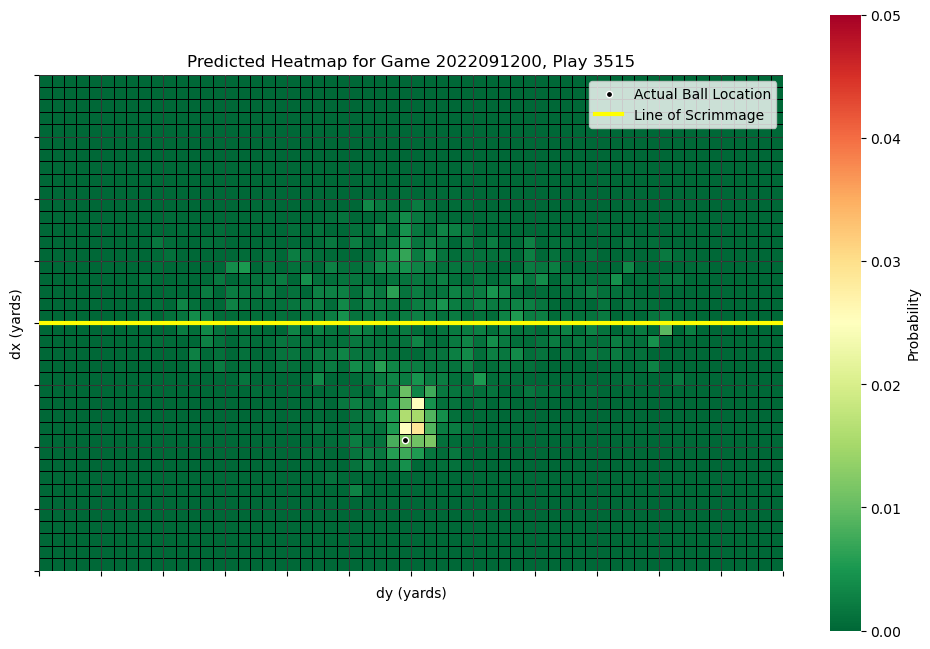

In [11]:
plot_play_prediction(
    game_id=2022091200,
    play_id=3515,#286,#
    x_data=x_data,
    y_data=raw_y_data,
    model=model,
    dx_bins=dx_bins,
    dy_bins=dy_bins
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


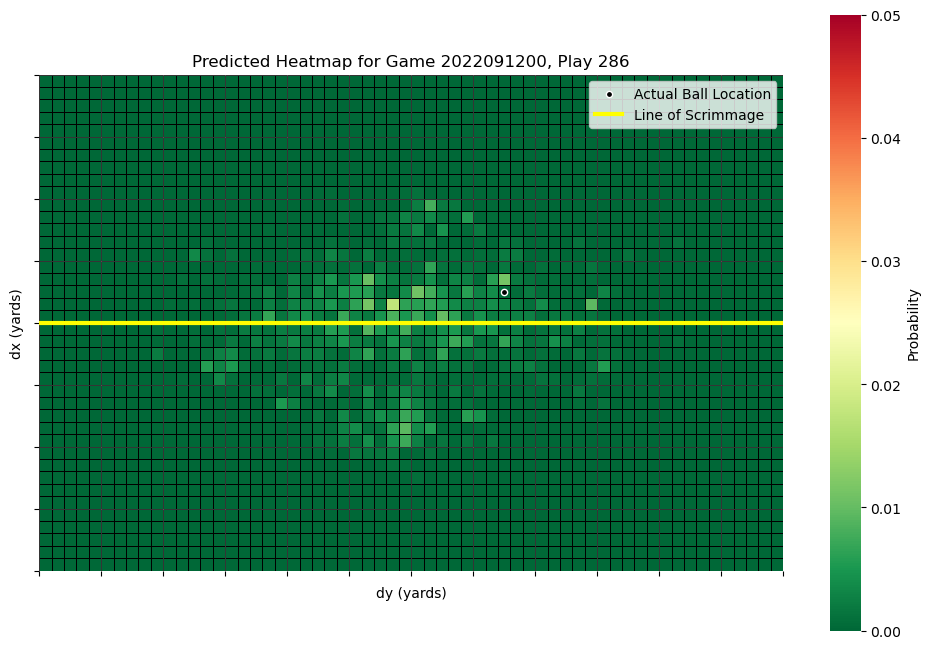

In [12]:
plot_play_prediction(
    game_id=2022091200,
    play_id=286,#,#
    x_data=x_data,
    y_data=raw_y_data,
    model=model,
    dx_bins=dx_bins,
    dy_bins=dy_bins
)

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_play_prediction(game_id, play_id, x_data, y_data, model, dx_bins, dy_bins):
    """
    Generate predictions for a specific play and visualize the results with a heatmap.

    Parameters:
    - game_id: The game ID for the play.
    - play_id: The play ID for the play.
    - x_data: The processed feature dataset.
    - y_data: The DataFrame with true dx and dy values.
    - model: The trained model.
    - dx_bins: Bins for the dx feature.
    - dy_bins: Bins for the dy feature.
    """
    # Step 1: Extract the play's processed data
    play_data = x_data[(x_data['gameId'] == game_id) & (x_data['playId'] == play_id)]
    
    if play_data.empty:
        print("Play not found!")
        return
    
    # Drop 'gameId' and 'playId' columns to match model input
    play_input = play_data.drop(columns=['gameId', 'playId']).values

    # Step 2: Get model predictions
    predictions = model.predict(play_input.reshape(1, -1))
    predicted_probs = predictions.reshape(len(dx_bins) - 1, len(dy_bins) - 1)
    
    # Step 3: Get truth data
    true_dx_dy = y_data[(y_data['gameId'] == game_id) & (y_data['playId'] == play_id)]
    if true_dx_dy.empty:
        print("Truth data not found!")
        return
    true_dx = true_dx_dy['dx'].values[0]
    true_dy = true_dx_dy['dy'].values[0]
    
    # Step 4: Create a heatmap for predictions
    plt.figure(figsize=(12, 8))
    
    # Set the color limits for the heatmap to standardize it across plays
    vmin = 0
    vmax = 1
    norm = plt.Normalize(vmin, vmax)
    
    ax = sns.heatmap(
        np.flipud(predicted_probs),  # Flip for positive to be in top-right
        cmap="RdYlGn_r",  # Light green to red, reversed for low to high
        xticklabels=dx_bins[::5],  # Set ticks every 5 yards for dx
        yticklabels=dy_bins[::5],  # Set ticks every 5 yards for dy
        cbar_kws={'label': 'Probability'},
        square=True,  # Make the heatmap square
        linewidths=0.5,
        linecolor='black',  # Add grid lines between cells
        vmin=vmin, vmax=vmax, norm=norm
    )
    
    # Adjust tick positions to be centered around zero
    ax.set_xticks(np.arange(len(dy_bins)) // 5 * 5)
    ax.set_yticks(np.arange(len(dx_bins)) // 5 * 5)

    # Add labels for tick marks
    ax.set_xticklabels(np.round(dy_bins[::5], 1))  # Adjust labels for dy ticks
    ax.set_yticklabels(np.round(np.flip(dx_bins[::5]), 1))  # Adjust labels for dx ticks

    # Step 5: Overlay true ball location
    true_dx_idx = np.digitize(true_dx, dx_bins) - 1
    true_dy_idx = np.digitize(true_dy, dy_bins) - 1
    plt.scatter(
        true_dy_idx + 0.5,  # Offset by 0.5 for centering
        (len(dx_bins) - 1 - true_dx_idx) + 0.5,  # Flip for consistency
        color='black',
        s=200,
        label='Actual Ball Location',
        edgecolor='white',
        zorder=5
    )
    
    # Add a horizontal yellow line at dy=0 (middle)
    plt.axhline(y=(len(dx_bins)-1)//2, color='yellow', linewidth=3, label='Zero Line')
    
    # Step 6: Add grid of 5x5 yards, focusing only on every 5-yard interval
    plt.grid(True, which='both', axis='both', linestyle='-', color='gray', linewidth=0.5, alpha=0.6)
    plt.xticks(np.arange(0, len(dy_bins), 5))  # Every 5 yards for dy
    plt.yticks(np.arange(0, len(dx_bins), 5))  # Every 5 yards for dx

    plt.title(f"Predicted Heatmap for Game {game_id}, Play {play_id}")
    plt.xlabel("dy (yards)")
    plt.ylabel("dx (yards)")
    plt.legend(loc='upper right')
    
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


ValueError: The number of FixedLocator locations (61), usually from a call to set_ticks, does not match the number of labels (13).

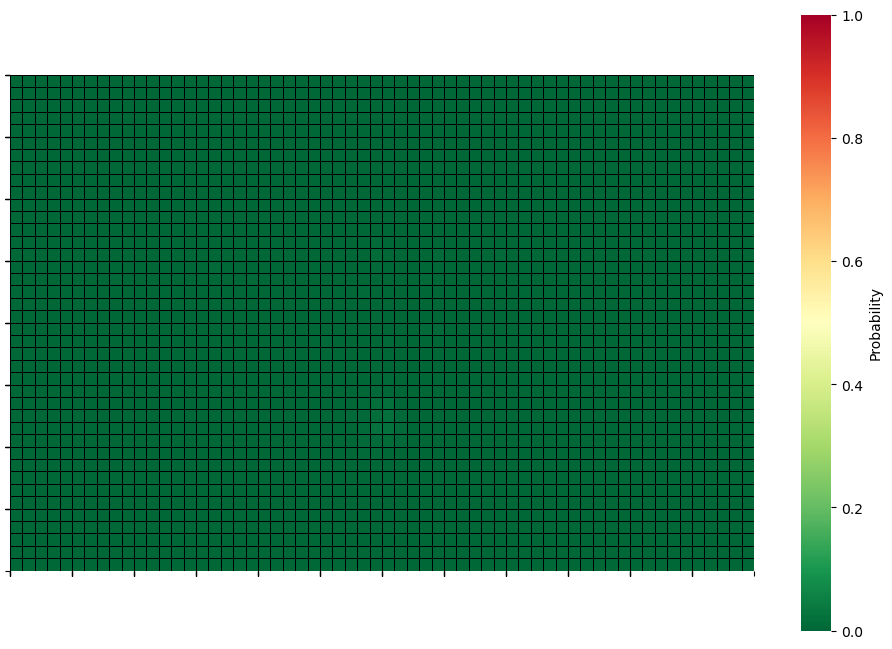

In [14]:
plot_play_prediction(
    game_id=2022091200,
    play_id=109,
    x_data=x_data,
    y_data=raw_y_data,
    model=model,
    dx_bins=dx_bins,
    dy_bins=dy_bins
)